In [ ]:
!apt-get update
!apt-get install -y wget unzip curl
!wget -q https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
!dpkg -i google-chrome-stable_current_amd64.deb || apt-get -f install -y
!google-chrome --version
!pip install selenium webdriver-manager

Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:4 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Hit:7 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease
Hit:8 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu jammy/main amd64 Packages [2,858 kB]
Get:10 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:11 https://r2u.stat.illinois.edu/ubuntu jammy/main all Packages [9,564 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [3,633 kB]
Get:13 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,205 kB]
Get:14 http:/

In [ ]:
import sys
sys.path.insert(0,'/usr/lib/chromium-browser/chromedriver')

import time
import random
import pandas as pd
import re
from bs4 import BeautifulSoup
from selenium import webdriver
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.stats import chi2_contingency
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [ ]:
options = webdriver.ChromeOptions()
options.add_argument('--headless')
options.add_argument('--no-sandbox')
options.add_argument('--disable-dev-shm-usage')
options.add_argument("user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/90.0.4430.212 Safari/537.36")

driver = webdriver.Chrome(options=options)

Задание 1-3

In [ ]:
driver.get('https://www.chipdip.ru/catalog-show/ceramic-fuses?ps=x3')
time.sleep(2)
soup = BeautifulSoup(driver.page_source, 'html.parser')

item = soup.find('div', class_='item')
driver.quit()

In [ ]:
def parsing(card_soup):
    row = {}
    # 1. Название и Ссылка
    link = card_soup.find('a', class_='link')
    if link:
        full_title = link.get('title', link.get_text(strip=True))
        row['URL'] = "https://www.chipdip.ru" + link.get('href', '')
    else:
        full_title = "Unknown"
        row['URL'] = ""

    # 2. Разделение Названия и Типа
    parts = re.split(r',\s+', full_title, maxsplit=1)
    if len(parts) > 1:
        name_prod = parts[0].strip()
        type_prod = parts[1].strip()
    else:
        name_prod = full_title
        type_prod = "Обычный"

    row['Название'] = name_prod
    row['Артикул'] = name_prod

    # Тип
    type_lower = type_prod.lower()
    if "быстро" in type_lower:
        row['Тип'] = "быстродействующий"
    elif "медлен" in type_lower:
        row['Тип'] = "медленный"
    else:
        row['Тип'] = "обычный"

    # 3. Цена
    price_span = card_soup.find('span', class_='price__value')
    if price_span:
        # Очистка цены от валюты и пробелов
        price = re.sub(r'[^\d.]', '', price_span.get_text(strip=True).replace(',', '.'))
        row['Цена'] = float(price) if price else 0.0
    else:
        row['Цена'] = 0.0

    # 4. Наличие (Количество)
    full_card_text = card_soup.get_text(" ", strip=True)
    stock_match = re.search(r'(\d+)\s*(?:шт|упак|налич)', full_card_text)

    if stock_match:
        row['Кол-во'] = int(stock_match.group(1))
        row['Срок поставки'] = "На складе"
    else:
        row['Кол-во'] = 0
        row['Срок поставки'] = "По запросу"

    # 5. Бренд
    mnf = card_soup.find('div', class_='item__mnf')
    row['Бренд'] = mnf.get_text(strip=True) if mnf else "Unknown"

    # Ток
    current = re.search(r'(\d+[.,]?\d*)\s*[АA]', full_title)
    row['ТОК'] = float(current.group(1).replace(',', '.')) if current else None

    # Напряжение
    voltage = re.search(r'(\d+)\s*[ВV](?![а-яА-Я])', full_title)
    row['Номинальное напряжение'] = int(voltage.group(1)) if voltage else None

    # Размеры
    dims = re.search(r'(\d+[.,]?\d*)\s*[xхXХ*×]\s*(\d+[.,]?\d*)', full_title)
    row['Размеры корпуса'] = f"{dims.group(1)}x{dims.group(2)}" if dims else None
    return row


In [ ]:
products = [] #прежде чем выполнить ячейку, надо еще раз выполнить ячейку с браузером
for i in range(1,21):
    url = f'https://www.chipdip.ru/catalog-show/ceramic-fuses?ps=x3&page={i}'
    driver.get(url)

    soup = BeautifulSoup(driver.page_source, 'html.parser')

    cards = soup.find_all('div', class_='item')
    print(f"Страница {i}: найдено {len(cards)} товаров")

    for i in cards:
        data = parsing(i)
        products.append(data)

Страница 1: найдено 60 товаров
Страница 2: найдено 60 товаров
Страница 3: найдено 60 товаров
Страница 4: найдено 60 товаров
Страница 5: найдено 60 товаров
Страница 6: найдено 60 товаров
Страница 7: найдено 60 товаров
Страница 8: найдено 60 товаров
Страница 9: найдено 60 товаров
Страница 10: найдено 60 товаров
Страница 11: найдено 60 товаров
Страница 12: найдено 60 товаров
Страница 13: найдено 60 товаров
Страница 14: найдено 60 товаров
Страница 15: найдено 60 товаров
Страница 16: найдено 60 товаров
Страница 17: найдено 60 товаров
Страница 18: найдено 60 товаров
Страница 19: найдено 60 товаров
Страница 20: найдено 60 товаров


In [ ]:
df = pd.DataFrame(parsed_data)
cols = ['Бренд', 'Название', 'Артикул', 'ТОК', 'Номинальное напряжение',
        'Размеры корпуса', 'Тип', 'Цена', 'Кол-во', 'Срок поставки']
for c in cols:
    if c not in df.columns:
        df[c] = None
df = df[cols]
df = df.drop_duplicates(subset=['Название'])

In [ ]:
df.head()

,Бренд,Название,Артикул,ТОК,Номинальное напряжение,Размеры корпуса,Тип,Цена,Кол-во,Срок поставки
0,XIBO,"Плавкие вставки 5×20 ВПБ 0,16А 250В (10 шт.)","Плавкие вставки 5×20 ВПБ 0,16А 250В (10 шт.)",0.16,250.0,5x20,быстродействующий,110.0,10,На складе
1,XIBO,"Плавкие вставки 5×20 ВПБ 0,25А 250В (10 шт.)","Плавкие вставки 5×20 ВПБ 0,25А 250В (10 шт.)",0.25,250.0,5x20,быстродействующий,110.0,10,На складе
2,XIBO,"Плавкие вставки 5×20 ВПБ 0,5А 250В (10 шт.)","Плавкие вставки 5×20 ВПБ 0,5А 250В (10 шт.)",0.50,250.0,5x20,быстродействующий,110.0,10,На складе
3,XIBO,"Плавкие вставки 5×20 ВПБ 1,25А 250В (10 шт.)","Плавкие вставки 5×20 ВПБ 1,25А 250В (10 шт.)",1.25,250.0,5x20,быстродействующий,110.0,10,На складе
4,XIBO,"Плавкие вставки 5×20 ВПБ 1,6А 250В (10 шт.)","Плавкие вставки 5×20 ВПБ 1,6А 250В (10 шт.)",1.60,250.0,5x20,быстродействующий,110.0,10,На складе


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1010 entries, 0 to 1199
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Бренд                   1010 non-null   object 
 1   Название                1010 non-null   object 
 2   Артикул                 1010 non-null   object 
 3   ТОК                     920 non-null    float64
 4   Номинальное напряжение  780 non-null    float64
 5   Размеры корпуса         387 non-null    object 
 6   Тип                     1010 non-null   object 
 7   Цена                    1010 non-null   float64
 8   Кол-во                  1010 non-null   int64  
 9   Срок поставки           1010 non-null   object 
dtypes: float64(3), int64(1), object(6)
memory usage: 86.8+ KB


Задание 4

In [ ]:
# 3. Группировка и агрегация
result = df.groupby('Тип').agg({
    'Цена': 'mean',
    'Кол-во': 'max',
    'Артикул': 'count'
}).reset_index()

# 4. Переименуем столбцы
result.columns = [
    'Тип',
    'Средняя цена',
    'Макс. кол-во на складе',
    'Число артикулов'
]

In [ ]:
result

,Тип,Средняя цена,Макс. кол-во на складе,Число артикулов
0,быстродействующий,5756.113402,16650,291
1,медленный,98.475728,24712,103
2,обычный,996.734740,74290,616


Задание 5

 5.1. Лучшие предохранители в каждой категории
                    Тип        Название     ТОК  Номинальное напряжение  \
1087  быстродействующий        170M6723  1000.0                  1400.0   
530           медленный       189140.16    16.0                   500.0   
649             обычный  20-004-13/400A   400.0                   500.0   

      Индекс качества      Цена  
1087         1.366667  124200.0  
530          1.640000     120.0  
649          1.500000    8770.0  

5.2. Пример данных с рассчитанными индексами
                 Тип                                      Название  \
0  быстродействующий  Плавкие вставки 5×20 ВПБ 0,16А 250В (10 шт.)   
1  быстродействующий  Плавкие вставки 5×20 ВПБ 0,25А 250В (10 шт.)   
2  быстродействующий   Плавкие вставки 5×20 ВПБ 0,5А 250В (10 шт.)   
3  быстродействующий  Плавкие вставки 5×20 ВПБ 1,25А 250В (10 шт.)   
4  быстродействующий   Плавкие вставки 5×20 ВПБ 1,6А 250В (10 шт.)   

   Индекс качества   Цена  
0         0.125107  1

/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: sharex is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)
/usr/local/lib/python3.12/dist-packages/seaborn/regression.py:598: UserWarning: sharey is deprecated from the `lmplot` function signature. Please update your code to pass it using `facet_kws`.
  warnings.warn(msg, UserWarning)


Text(0.5, 1.05, '5.3 Зависимость Цены от Индекса качества по типам')

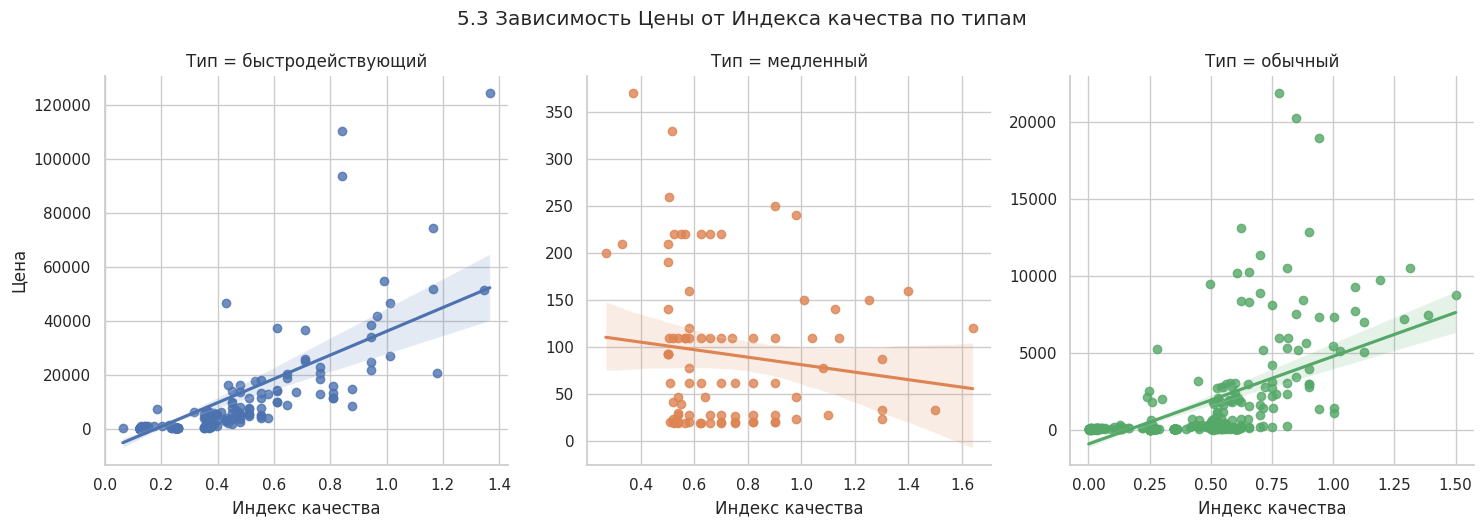

In [ ]:
# 1. Находим максимальные значения Тока и Напряжения внутри каждой группы 'Тип'
max_values = df.groupby('Тип')[['ТОК', 'Номинальное напряжение']].transform('max')

# 2. Рассчитываем относительные показатели (значение / лучшее_в_группе)
df['rel_tok'] = df['ТОК'] / max_values['ТОК']
df['rel_volt'] = df['Номинальное напряжение'] / max_values['Номинальное напряжение']

# 3. Суммируем, чтобы получить Индекс Качества
df['Индекс качества'] = df['rel_tok'] + df['rel_volt']

# Вывод "Самых лучших" предохранителей в каждой категории (у кого индекс максимальный)
print(" 5.1. Лучшие предохранители в каждой категории")
best_indices = df.groupby('Тип')['Индекс качества'].idxmax()
best_fuses = df.loc[best_indices, ['Тип', 'Название', 'ТОК', 'Номинальное напряжение', 'Индекс качества', 'Цена']]
print(best_fuses)

print("\n5.2. Пример данных с рассчитанными индексами")
print(df[['Тип', 'Название', 'Индекс качества', 'Цена']].head())


sns.set_theme(style="whitegrid")
g = sns.lmplot(
    data=df,
    x="Индекс качества",
    y="Цена",
    col="Тип",
    hue="Тип",
    height=5,
    aspect=1,
    sharex=False,
    sharey=False
)

g.fig.suptitle('5.3 Зависимость Цены от Индекса качества по типам', y=1.05)

Задание 6

Сводная таблица по ценовым сегментам
                    Цена Индекс качества             Название
                    mean            mean   min   max    count
Ценовой сегмент                                              
Эконом             44.37            0.23  0.00  1.50      386
Стандарт          164.97            0.33  0.00  1.30      294
Премиум          6768.27            0.64  0.13  1.64      330


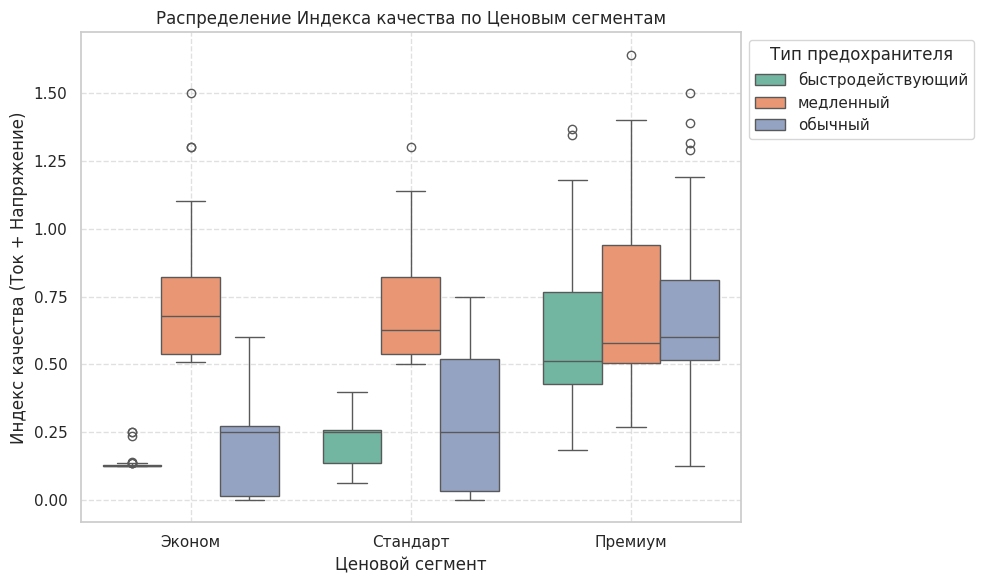

In [ ]:
# 1. Функция для сегментации
def get_price_segment(series):
    # Делим на 3 сегмента:
    # 0-33% -> Эконом
    # 33-66% -> Стандарт
    # 66-100% -> Премиум
    try:
        return pd.qcut(series, q=3, labels=['Эконом', 'Стандарт', 'Премиум'], duplicates='drop')
    except ValueError:
        return 'Стандарт'


# 2. Применяем сегментацию внутри каждой группы 'Тип'

df['Ценовой сегмент'] = df.groupby('Тип')['Цена'].transform(get_price_segment)

# 3. Анализ: Как Индекс качества соотносится с ценовым сегментом
# Мы используем полученные ранее индексы качества, чтобы проверить гипотезу:

# Группируем по Сегменту и считаем средний Индекс качества и среднюю Цену
summary = df.groupby('Ценовой сегмент', observed=False).agg({
    'Цена': 'mean',
    'Индекс качества': ['mean', 'min', 'max'],
    'Название': 'count'
}).round(2)

print("Сводная таблица по ценовым сегментам")
print(summary)

# 4. Визуализация

plt.figure(figsize=(10, 6))
sns.boxplot(
    data=df,
    x='Ценовой сегмент',
    y='Индекс качества',
    hue='Тип',
    palette="Set2"
)
plt.title('Распределение Индекса качества по Ценовым сегментам')
plt.xlabel('Ценовой сегмент')
plt.ylabel('Индекс качества (Ток + Напряжение)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Тип предохранителя', loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()

Задание 7

In [ ]:
# 1. Создаем функцию для оценки "тяжести" срока поставки
def get_delivery_rank(value):
    val_lower = str(value).lower()
    #if "склад" in val_lower or "налич" in val_lower:
        #return 0  # Самый быстрый (мгновенно)
    if "день" in val_lower or "дн." in val_lower:
        return 10 # Быстро (дни)
    elif "недел" in val_lower:
        return 50 # Долго (недели)
    elif "запрос" in val_lower:
        return 100 # Очень долго (неизвестно)
    else:
        return 99 # Непонятный статус, считаем долгим

# 2. Применяем ранжирование
df_analysis = df.copy()
df_analysis['Ранг поставки'] = df_analysis['Срок поставки'].apply(get_delivery_rank)

# 3. Сортировка:
deficit_df = df_analysis.sort_values(
    by=['Кол-во', 'Ранг поставки'],
    ascending=[True, False]
)

# 4. Выбор победителя
worst_fuse = deficit_df.iloc[0]

print("Самый дефицитный предохранитель")
print(f"Название:      {worst_fuse['Название']}")
print(f"Тип:           {worst_fuse['Тип']}")
print(f"Остаток:       {worst_fuse['Кол-во']} шт.")
print(f"Срок поставки: {worst_fuse['Срок поставки']}")
print(f"Цена:          {worst_fuse['Цена']}")

Самый дефицитный предохранитель
Название:      16A 500V 10x38mm
Тип:           обычный
Остаток:       0 шт.
Срок поставки: По запросу
Цена:          20.0


Задание 8

Порог разделения по Току: 5.0 А
Порог разделения по Напряжению: 250.0 В

Таблица сопряженности (кол-во штук)
Группа Напряжения  Напряжение: Высокое  Напряжение: Низкое
Группа Тока                                               
Ток: Высокий                       253                 117
Ток: Низкий                         81                 295


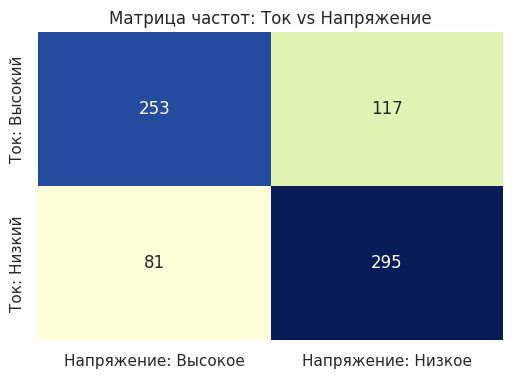


Результаты теста Хи-квадрат:
Chi2 Statistic: 163.5515
P-value:        1.8956e-37


In [ ]:
work_df = df.dropna(subset=['ТОК', 'Номинальное напряжение']).copy()

# 8.1. Разбиение на группы
median_current = work_df['ТОК'].median()
median_voltage = work_df['Номинальное напряжение'].median()

# Функция для категоризации
def categorize_current(val):
    return 'Ток: Высокий' if val > median_current else 'Ток: Низкий'

def categorize_voltage(val):
    return 'Напряжение: Высокое' if val > median_voltage else 'Напряжение: Низкое'

work_df['Группа Тока'] = work_df['ТОК'].apply(categorize_current)
work_df['Группа Напряжения'] = work_df['Номинальное напряжение'].apply(categorize_voltage)

print(f"Порог разделения по Току: {median_current} А")
print(f"Порог разделения по Напряжению: {median_voltage} В")

# 8.2. Таблица сопряженности
contingency_table = pd.crosstab(work_df['Группа Тока'], work_df['Группа Напряжения'])

print("\nТаблица сопряженности (кол-во штук)")
print(contingency_table)

plt.figure(figsize=(6, 4))
sns.heatmap(contingency_table, annot=True, fmt='d', cmap="YlGnBu", cbar=False)
plt.title('Матрица частот: Ток vs Напряжение')
plt.ylabel('')
plt.xlabel('')
plt.show()

# 8.3. Тест Хи-квадрат (Chi-Square Test)
chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("\nРезультаты теста Хи-квадрат:")
print(f"Chi2 Statistic: {chi2:.4f}")
print(f"P-value:        {p_value:.4e}")

Так как p < 0.05, то связь между током и напряжением есть

Задание 9

Text(66.24999999999999, 0.5, 'Категория Тока')

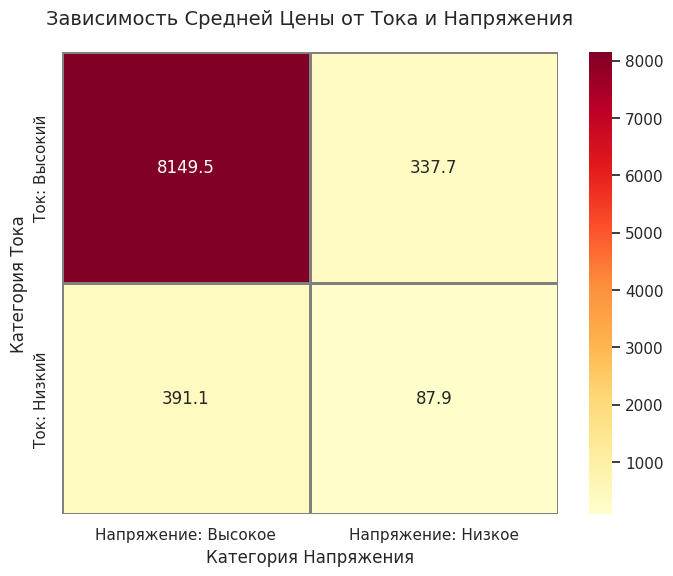

In [ ]:
# 1. Создаем сводную таблицу для тепловой карты
heatmap_data = work_df.pivot_table(
    index='Группа Тока',
    columns='Группа Напряжения',
    values='Цена',
    aggfunc='mean'
)

# 2. Построение графика
plt.figure(figsize=(8, 6))
sns.heatmap(heatmap_data, annot=True, fmt=".1f", cmap="YlOrRd", linewidths=1, linecolor='gray')
plt.title('Зависимость Средней Цены от Тока и Напряжения', fontsize=14, pad=20)
plt.xlabel('Категория Напряжения', fontsize=12)
plt.ylabel('Категория Тока', fontsize=12)

Задание 10

Качество модели (R^2): 0.59


/tmp/ipython-input-1688643171.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance, x='Влияние (Вес)', y='Характеристика', palette='viridis')


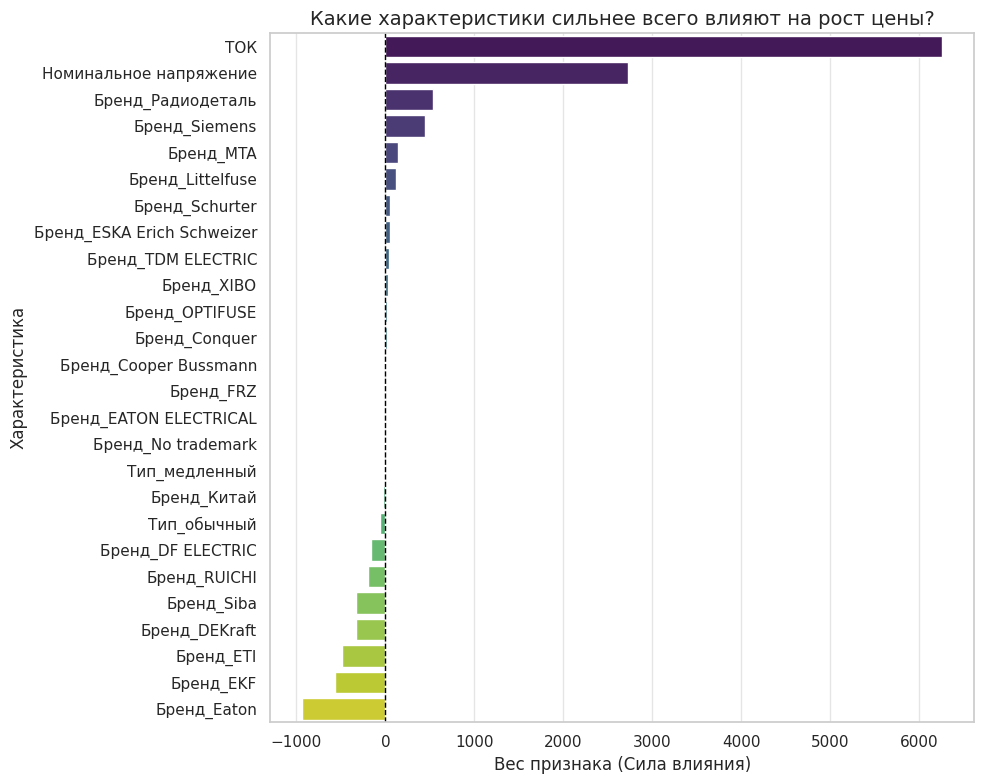


Топ-5 факторов, повышающих цену
            Характеристика  Влияние (Вес)
0                      ТОК    6253.898880
1   Номинальное напряжение    2728.235229
25       Бренд_Радиодеталь     534.741609
21           Бренд_Siemens     447.817379
15               Бренд_MTA     145.792581

Топ-5 факторов, снижающих цену
   Характеристика  Влияние (Вес)
20     Бренд_Siba    -333.213987
6   Бренд_DEKraft    -333.478879
11      Бренд_ETI    -486.510544
9       Бренд_EKF    -559.993626
12    Бренд_Eaton    -933.302853


In [ ]:

#Подготовка данных
cols_to_use = ['ТОК', 'Номинальное напряжение', 'Тип', 'Бренд', 'Цена']

# Создаем копию и удаляем пустые строки
model_df = df[cols_to_use].dropna().copy()

# 1. Кодирование категориальных признаков (тип, бренд)
X_raw = pd.get_dummies(model_df.drop('Цена', axis=1), drop_first=True)
y = model_df['Цена']

# 2. Масштабирование данных
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)
X = pd.DataFrame(X_scaled, columns=X_raw.columns)

# 3. Разделение на обучение и тест
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Обучение Линейной Регрессии
model = LinearRegression()
model.fit(X_train, y_train)

#5. Оценка качества модели (R^2)
r2_score = model.score(X_test, y_test)
print(f"Качество модели (R^2): {r2_score:.2f}")

# 5. Анализ важности признаков
# Создаем таблицу: Признак - Его Вес
importance = pd.DataFrame({
    'Характеристика': X.columns,
    'Влияние (Вес)': model.coef_
})
importance = importance.sort_values(by='Влияние (Вес)', ascending=False)

# 6. Визуализация
plt.figure(figsize=(10, 8))
sns.barplot(data=importance, x='Влияние (Вес)', y='Характеристика', palette='viridis')

plt.title('Какие характеристики сильнее всего влияют на рост цены?', fontsize=14)
plt.xlabel('Вес признака (Сила влияния)', fontsize=12)
plt.ylabel('Характеристика', fontsize=12)
plt.axvline(x=0, color='black', linestyle='--', linewidth=1) # Линия нуля
plt.grid(axis='x', alpha=0.5)
plt.tight_layout()
plt.show()

print("\nТоп-5 факторов, повышающих цену")
print(importance.head(5))

print("\nТоп-5 факторов, снижающих цену")
print(importance.tail(5))